In [1]:
import numpy as np

import sys
sys.path.append('/home/mark/Documents/Kea')
import kea
from kea.statistics.spectra import fourier_modal_spectrum, bt_modal_spectrum, esf_integrated_spectrum, dog_averaged_spectrum
from kea.statistics.statfunc import complete_symmetric_correlation_function, structure_function, set_calculation_mode
from kea.simulator import mff

from kea.utils import geometry

import matplotlib.pyplot as plt

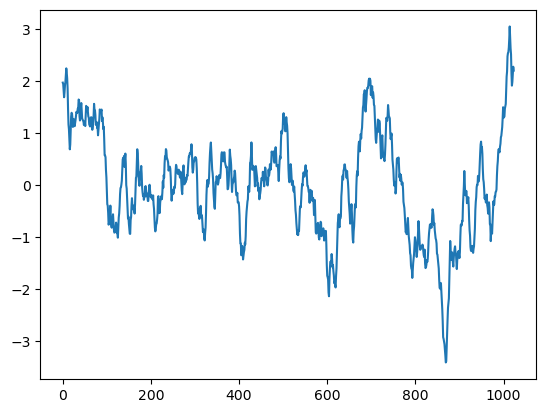

In [2]:
D = 1
N = 1024
kk = mff.make_grid(N, D)
field = mff.make_mff(kk[1], 2.*np.pi, 2./3., N)
plt.plot(field)

In [3]:
geometry.DEFAULT_PHYS_SCALE = 3.*np.pi
dx, dk = geometry.get_dxdk((N,)*D)
print(dx)

(0.009203884727313847,)


In [4]:
kp, fekp = fourier_modal_spectrum(field)

In [5]:
set_calculation_mode(use_gpu=True, use_cpu=False)

Set statistic function calculation flags: {CALCULATION_MODE_FLAGS}


(<CalculationMode.USE_GPU: 1>,)

In [6]:
ell, acf_full = complete_symmetric_correlation_function(field)
kc, fekc = bt_modal_spectrum(acf_full)

In [6]:
kd, fekd = dog_averaged_spectrum(field)

In [7]:
ell, sf = structure_function(field)
ks, _, feks = esf_integrated_spectrum(ell[:,0]*dx[0], sf[:,0], D)

/home/mark/Documents/Kea/kea/statistics/spectra/equiv_spectrum.py:81: RuntimeWarning: divide by zero encountered in divide
  ke = b / ell
/home/mark/miniconda3/envs/astro/lib/python3.13/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


(1e-06, 10.0)

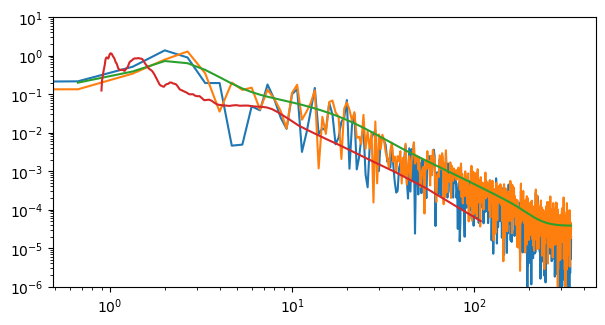

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(7., 3.5))

ax.plot(kp[0], fekp)
ax.plot(kc[0], fekc)
ax.plot(kd, fekd)
## WHY A FACTOR OF 2 HERE???
ax.plot(ks, feks)

ax.loglog()

ax.set_ylim((1e-6, 1e1))